In [1]:
pip install shap scikit-learn pandas matplotlib seaborn

INFO: pip is looking at multiple versions of scikit-learn to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of matplotlib to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 720.9 kB/s eta 0:00:00:--:--
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 566.0 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━

In [3]:
!pip install "numpy<2" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 331.6 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 121.4 kB/s eta 0:00:0000:0100:04
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [2]:
import shap
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

print("SHAP, scikit-learn, pandas, numpy, matplotlib, seaborn imported successfully!")
print(f"SHAP version: {shap.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"pandas version: {pd.__version__}")

# --- Simulate a Cybersecurity Dataset ---
# Let's create a dataset with features relevant to network intrusion detection
# Features could represent: packet size, protocol type, duration, flags, etc.
n_samples = 1000
n_features = 10

X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=5,  # Number of informative features
    n_redundant=2,    # Number of redundant features
    n_classes=2,      # Binary classification (e.g., Benign/Malicious)
    random_state=42
)

# Convert to DataFrame for better readability and feature naming
feature_names = [f'feature_{i}' for i in range(n_features)]
X_df = pd.DataFrame(X, columns=feature_names)

# Add some potentially more meaningful feature names for context
feature_names_context = [
    'packet_size', 'protocol_type', 'duration', 'src_port', 'dst_port',
    'flags_syn', 'flags_ack', 'payload_len', 'ttl', 'entropy'
]
if n_features == len(feature_names_context):
    X_df.columns = feature_names_context
    feature_names = feature_names_context # Update feature_names for later use

print(f"\nGenerated synthetic dataset with {X_df.shape[0]} samples and {X_df.shape[1]} features.")
print("First 5 rows of the dataset:")
print(X_df.head())

# --- Train a Simple Model ---
# Using RandomForestClassifier as it's common and works well with SHAP
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"\nModel trained successfully. Test accuracy: {accuracy:.4f}")

# Expected output: You should see accuracy > 0.80 (depending on synthetic data generation)
if accuracy < 0.80:
    print("Warning: Model accuracy is lower than expected. This might affect SHAP interpretation.")

# --- SHAP Explanation Setup ---
# We need an explainer object. TreeExplainer is efficient for tree-based models.
# If using other models (e.g., deep learning, linear models), use appropriate explainers.
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
# This can take time for large datasets
print("\nCalculating SHAP values for the test set... This may take a few minutes.")
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

# For multi-class classification, shap_values is a list of arrays (one per class).
# For binary classification, it's often a single array (for the positive class).
# We'll assume binary classification here and use the values for the positive class.
#if isinstance(shap_values, list):
#    shap_values_positive_class = shap_values[1] # Assuming class 1 is the positive class
#else:
#    shap_values_positive_class = shap_values
# Check the shape to handle different SHAP versions
if len(shap_values.shape) == 3:
    # shape is (samples, features, classes), we want class 1 (positive)
    shap_values_positive_class = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    # Older SHAP versions returned a list of arrays
    shap_values_positive_class = shap_values[1]
else:
    shap_values_positive_class = shap_values

# Now this will work because shap_values_positive_class is 2D (200, 10)
shap_df = pd.DataFrame(shap_values_positive_class, columns=[f'shap_{col}' for col in X_test.columns])

# Store SHAP values in a DataFrame for easier manipulation if needed
shap_df = pd.DataFrame(shap_values_positive_class, columns=[f'shap_{col}' for col in X_test.columns])

print("\nFirst 5 rows of SHAP values for the positive class:")
print(shap_df.head())

# --- Save necessary objects for later use (optional but good practice) ---
# In a real lab, you might save the model, explainer, and shap_values
# For this lesson, we'll keep them in memory.

print("\nLab setup complete. Ready for visualization and analysis.")

SHAP, scikit-learn, pandas, numpy, matplotlib, seaborn imported successfully!
SHAP version: 0.51.0
scikit-learn version: 1.8.0
pandas version: 2.1.1

Generated synthetic dataset with 1000 samples and 10 features.
First 5 rows of the dataset:
   packet_size  protocol_type  duration  src_port  dst_port  flags_syn  \
0     1.125100       1.178124  0.493516  0.790880 -0.614278   1.347020   
1    -0.564641       3.638629 -1.522415 -1.541705  1.616697   4.781310   
2     0.516313       2.165426 -0.628486 -0.386923  0.492518   1.442381   
3     0.537282       0.966618 -0.115420  0.670755 -0.958516   0.871440   
4     0.278385       1.065828 -1.724917 -2.235667  0.715107   0.731249   

   flags_ack  payload_len       ttl   entropy  
0   1.419515     1.357325  0.966041 -1.981139  
1   3.190292    -0.890254  1.438826 -3.828748  
2   1.332905    -1.958175 -0.348803 -1.804124  
3   0.508186    -1.034471 -1.654176 -1.910503  
4  -0.674119     0.598330 -0.524283  1.047610  

Model trained successful

In [ ]:
# Step 2: Generate and Interpret the SHAP Summary Plot


Generating SHAP Summary Plot...


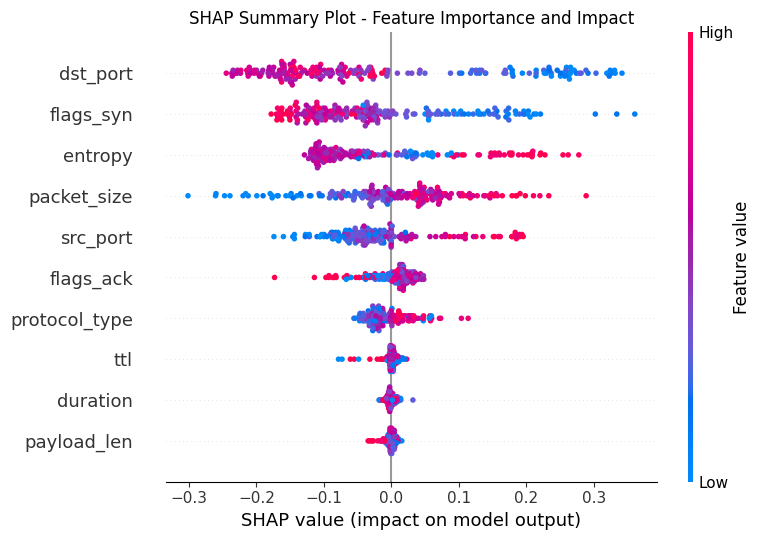

SHAP Summary Plot generated.

Interpreting the SHAP Summary Plot:
- Features are ordered by overall importance (mean absolute SHAP value) from top to bottom.
- Each dot represents a single SHAP value for a specific feature and instance.
- The horizontal position indicates the impact: right (positive SHAP value) pushes prediction higher, left (negative SHAP value) pushes prediction lower.
- The color of the dot indicates the original value of the feature: typically red for high values and blue for low values.
- Observe which features have the widest spread of SHAP values and how their original values (colors) correlate with the impact (position).

Generating SHAP Bar Plot for overall feature importance...


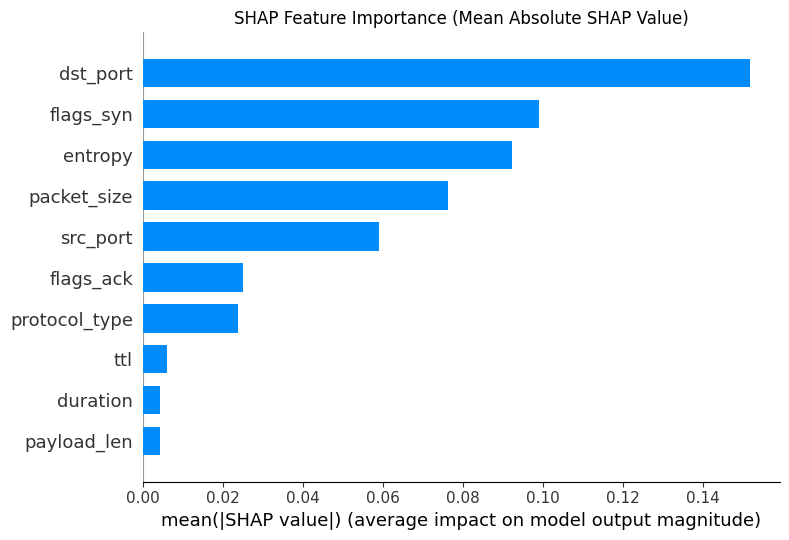

SHAP Bar Plot generated.

Interpretation of Bar Plot:
- This plot directly shows the average impact of each feature across all instances, regardless of the direction of impact.
- Features with longer bars are generally more important for the model's predictions.


In [3]:
# --- Generate SHAP Summary Plot ---
print("\nGenerating SHAP Summary Plot...")

# Ensure shap_values_positive_class and X_test are available from previous step
# If running this as a separate cell, ensure these variables are loaded or recomputed.

# For TreeExplainer, shap_values can be a list (for multi-class) or a single array (for binary).
# We've handled binary case above, assuming shap_values_positive_class is ready.

# Use the original feature names for clarity
feature_names_for_plot = X_test.columns.tolist()

# Create the summary plot
# plot_type='dot' is the default and shows individual SHAP values
# plot_type='bar' shows only the mean absolute SHAP value for each feature

snap = shap.summary_plot(shap_values_positive_class, X_test, feature_names=feature_names_for_plot, plot_type='dot', show=False)

plt.title('SHAP Summary Plot - Feature Importance and Impact')
plt.tight_layout()
plt.show()

print("SHAP Summary Plot generated.")

# --- Interpretation Guidance ---
print("\nInterpreting the SHAP Summary Plot:")
print("- Features are ordered by overall importance (mean absolute SHAP value) from top to bottom.")
print("- Each dot represents a single SHAP value for a specific feature and instance.")
print("- The horizontal position indicates the impact: right (positive SHAP value) pushes prediction higher, left (negative SHAP value) pushes prediction lower.")
print("- The color of the dot indicates the original value of the feature: typically red for high values and blue for low values.")
print("- Observe which features have the widest spread of SHAP values and how their original values (colors) correlate with the impact (position).")

# --- Generate SHAP Bar Plot (alternative view of importance) ---
print("\nGenerating SHAP Bar Plot for overall feature importance...")
snap_bar = shap.summary_plot(shap_values_positive_class, X_test, feature_names=feature_names_for_plot, plot_type='bar', show=False)

plt.title('SHAP Feature Importance (Mean Absolute SHAP Value)')
plt.tight_layout()
plt.show()

print("SHAP Bar Plot generated.")
print("\nInterpretation of Bar Plot:")
print("- This plot directly shows the average impact of each feature across all instances, regardless of the direction of impact.")
print("- Features with longer bars are generally more important for the model's predictions.")


Generating SHAP Dependence Plots...
Using feature 'duration' for coloring in dependence plots.

Generating dependence plot for 'packet_size'...


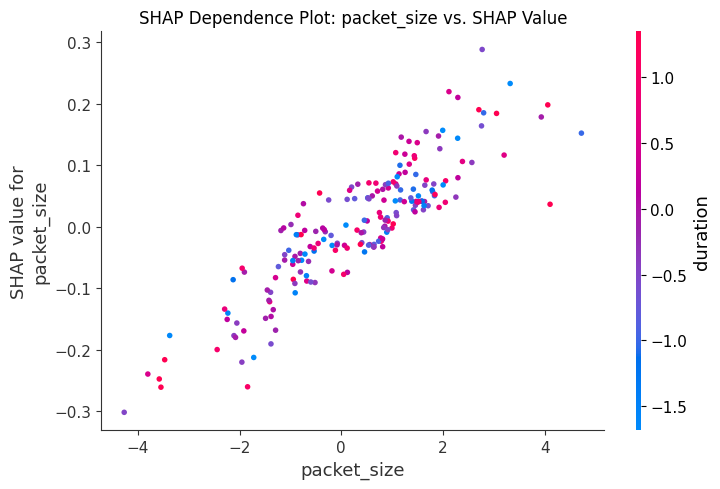

Dependence plot for 'packet_size' generated.

Generating dependence plot for 'protocol_type'...


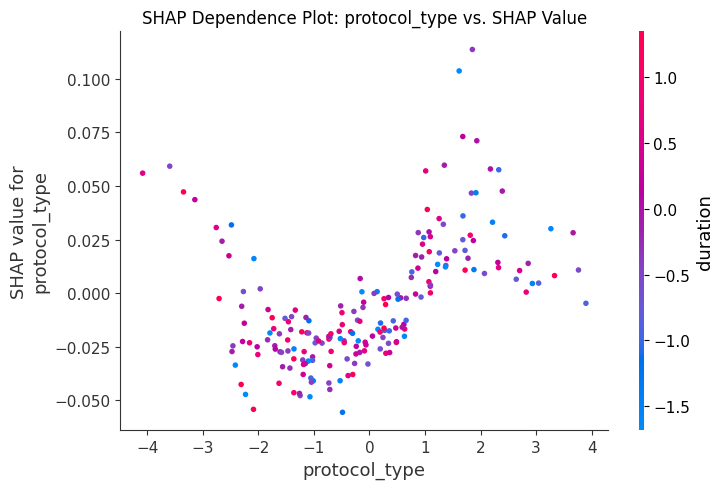

Dependence plot for 'protocol_type' generated.

SHAP Dependence Plots generation complete.

Interpreting SHAP Dependence Plots:
- The x-axis shows the actual value of the feature being analyzed.
- The y-axis shows the SHAP value for that feature, indicating its impact on the prediction.
- Observe the trend: Does the SHAP value generally increase, decrease, or stay flat as the feature value changes?
- If a 'color_feature' was specified, the color of the points indicates the value of that interaction feature.
- Look for patterns in color: Do points of a certain color (e.g., high values of the interaction feature) cluster in specific areas of the plot, suggesting an interaction?
- In cybersecurity, this can reveal thresholds or conditions where a feature's importance changes dramatically, possibly due to interactions with other threat indicators.


In [4]:
# --- Generate SHAP Dependence Plots ---
print("\nGenerating SHAP Dependence Plots...")

# Select a couple of important features from the summary plot for deeper analysis
# Let's assume 'packet_size' and 'duration' were identified as important.
# Replace with actual important feature names from your summary plot if different.
important_features = X_test.columns.tolist()[:2] # Taking the first two features as examples

# Choose a feature to color by, potentially another important one or one suspected of interaction
# Let's use the third feature for coloring, assuming it might interact.
color_feature_index = 2
if len(X_test.columns) > color_feature_index:
    color_feature_name = X_test.columns[color_feature_index]
else:
    # Fallback if there aren't enough features
    color_feature_name = X_test.columns[0] if len(X_test.columns) > 0 else None
    print(f"Warning: Not enough features for a distinct color feature. Using '{color_feature_name}' for coloring.")

if color_feature_name:
    print(f"Using feature '{color_feature_name}' for coloring in dependence plots.")

for feature_name in important_features:
    if color_feature_name and feature_name == color_feature_name:
        print(f"Skipping dependence plot for '{feature_name}' as it's the same as the color feature.")
        continue

    print(f"\nGenerating dependence plot for '{feature_name}'...")
    try:
        shap.dependence_plot(
            feature_name,
            shap_values_positive_class,
            X_test,
            feature_names=feature_names_for_plot,
            interaction_index=color_feature_name if color_feature_name else 'auto',
            show=False
        )
        plt.title(f'SHAP Dependence Plot: {feature_name} vs. SHAP Value')
        plt.tight_layout()
        plt.show()
        print(f"Dependence plot for '{feature_name}' generated.")
    except Exception as e:
        print(f"Could not generate dependence plot for {feature_name}: {e}")

print("\nSHAP Dependence Plots generation complete.")

# --- Interpretation Guidance for Dependence Plots ---
print("\nInterpreting SHAP Dependence Plots:")
print("- The x-axis shows the actual value of the feature being analyzed.")
print("- The y-axis shows the SHAP value for that feature, indicating its impact on the prediction.")
print("- Observe the trend: Does the SHAP value generally increase, decrease, or stay flat as the feature value changes?")
print("- If a 'color_feature' was specified, the color of the points indicates the value of that interaction feature.")
print("- Look for patterns in color: Do points of a certain color (e.g., high values of the interaction feature) cluster in specific areas of the plot, suggesting an interaction?")
print("- In cybersecurity, this can reveal thresholds or conditions where a feature's importance changes dramatically, possibly due to interactions with other threat indicators.")

In [8]:
# --- Generate Local SHAP Explanation for a Single Instance ---
print("\nGenerating local SHAP explanation for a single instance...")

# Select a single instance from the test set (e.g., the first one)
instance_index = 0

if instance_index < len(X_test):
    single_instance = X_test.iloc[[instance_index]]
    single_instance_shap_values = explainer.shap_values(single_instance)

    # 1. Handle SHAP values based on dimensionality (fixes the 2D/3D mismatch)
    if len(single_instance_shap_values.shape) == 3:
        # Shape is (1, 10, 2) -> Pull [instance 0, all features, class 1]
        shap_values_for_instance = single_instance_shap_values[0, :, 1]
    elif isinstance(single_instance_shap_values, list):
        # Older SHAP version returning list of arrays
        shap_values_for_instance = single_instance_shap_values[1][0]
    else:
        # Standard 2D array fallback
        shap_values_for_instance = single_instance_shap_values[0]
    
    # 2. Get the model's prediction and probabilities
    prediction = model.predict(single_instance)[0]
    prediction_proba = model.predict_proba(single_instance)[0]

    # 3. Handle Expected Value (Baseline) carefully to avoid TypeErrors
    expected_value = explainer.expected_value
    # If it's an array/list of classes, select the positive class (index 1)
    if isinstance(expected_value, (np.ndarray, list)) and len(expected_value) > 1:
        expected_value = expected_value[1]
    
    # FORCE to scalar float to ensure print formatting works
    if hasattr(expected_value, 'item'):
        expected_value = expected_value.item()
    else:
        expected_value = float(expected_value)

    # 4. Calculate verification metrics
    sum_of_shap_values = float(np.sum(shap_values_for_instance))
    reconstructed_prediction = float(expected_value + sum_of_shap_values)

    print(f"\nAnalysis for instance index: {instance_index}")
    print(f"Model Prediction: {prediction} (Probability: {prediction_proba[prediction]:.4f})")
    print(f"Expected Value (Baseline): {expected_value:.4f}")
    print(f"Sum of SHAP values: {sum_of_shap_values:.4f}")
    print(f"Reconstructed Prediction (Expected + Sum of SHAP): {reconstructed_prediction:.4f}")
    print(f"Original Prediction: {prediction_proba[1]:.4f} (for positive class)")

    # 5. Verify local accuracy
    if np.isclose(reconstructed_prediction, prediction_proba[1]):
        print("\nLocal accuracy verified: Sum of SHAP values + Expected Value ≈ Model Prediction.")
    else:
        print("\nWarning: Local accuracy verification shows a discrepancy.")

    # 6. Visualize the local explanation using the force plot
    print("\nGenerating SHAP Force Plot for the instance...")
    
    # Initialize JS for the notebook
    shap.initjs() 
    
    # Generate the plot
    # We set show=False so we can handle the display ourselves
    plot = shap.force_plot(
        expected_value,
        shap_values_for_instance,
        single_instance,
        matplotlib=False
    )
    
    # Use the standard IPython display instead of shap.display
    from IPython.display import display
    display(plot)
    
    print("SHAP Force Plot generated.")


Generating local SHAP explanation for a single instance...

Analysis for instance index: 0
Model Prediction: 0 (Probability: 0.9800)
Expected Value (Baseline): 0.5192
Sum of SHAP values: -0.4992
Reconstructed Prediction (Expected + Sum of SHAP): 0.0200
Original Prediction: 0.0200 (for positive class)

Local accuracy verified: Sum of SHAP values + Expected Value ≈ Model Prediction.

Generating SHAP Force Plot for the instance...


SHAP Force Plot generated.
